In [2]:
from pathlib import Path
ROOT = Path('..').resolve()
DATA_DIR = ROOT / 'data'
IMG_DIR = DATA_DIR / 'images'

In [3]:
import pandas as pd

data = pd.read_csv(f'{DATA_DIR}/dataset_final.csv')
print(data.head())

   emotion                                          utterance      art_style  \
0  sadness  This painting shows a gloomy day. The darkness...        Realism   
1  sadness       the weather and atmosphere makes me feel sad    Romanticism   
2  sadness      Dark and moody, cloudy sky that is depressing  Impressionism   
3  sadness             the picture is dark with a somber tone  Impressionism   
4  sadness      the dark colors make the painting look gloomy  Impressionism   

                                         painting anchor_art_style  \
0            johan-hendrik-weissenbruch_windy-day          Realism   
1  ivan-aivazovsky_landscape-with-a-schooner-1880          Realism   
2                      paul-gauguin_clearing-1873          Realism   
3           john-henry-twachtman_winter-landscape          Realism   
4           eugene-boudin_trouville-the-port-1864          Realism   

                               anchor_painting  repetition  \
0        johan-hendrik-weissenbruch_

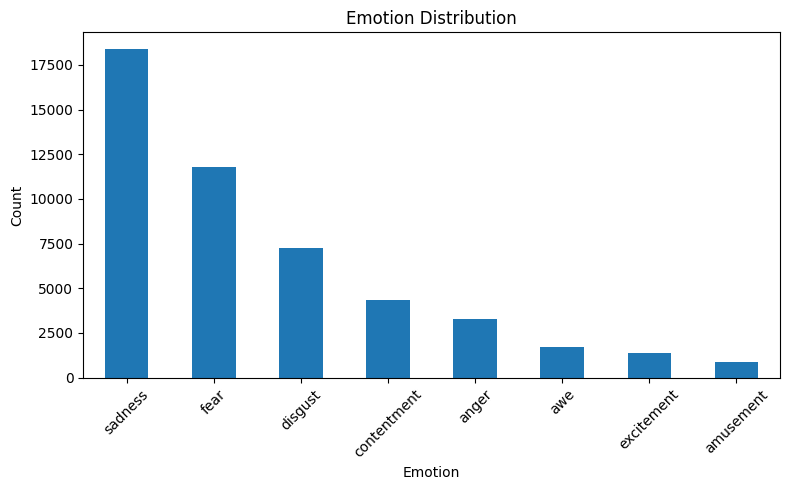

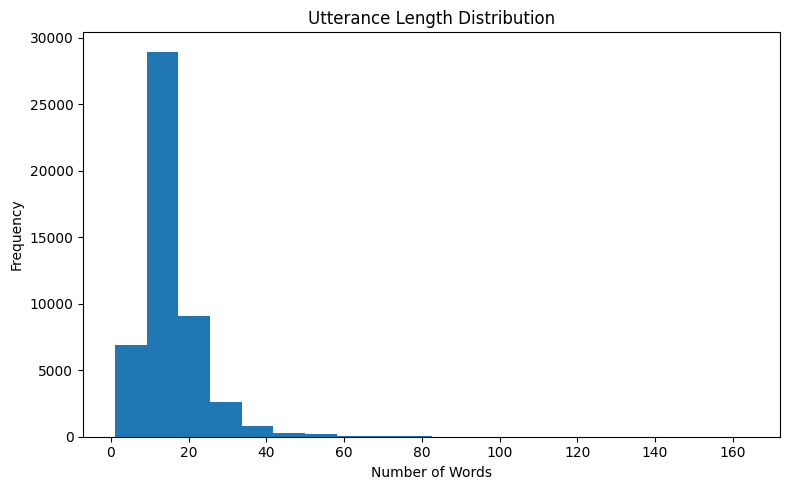

Unique images: 49056
Actual images in directory: 49062
Invalid image references: 0
count    49056.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
dtype: float64
(49056, 8)


In [8]:
import matplotlib.pyplot as plt
emotion_distribution = data['emotion'].value_counts()
plt.figure(figsize=(8, 5))
emotion_distribution.plot(kind='bar')
plt.title('Emotion Distribution')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



plt.figure(figsize=(8, 5))
plt.hist(data['utterance'].apply(lambda x: len(x.split())), bins=20)
plt.title('Utterance Length Distribution')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

image_coverage = data['filename'].nunique()
print(f'Unique images: {image_coverage}')
actual_images_count = len(list(IMG_DIR.glob('*.jpg')))
print(f'Actual images in directory: {actual_images_count}')

invalid_images = set(data['filename']) - set(img.name for img in IMG_DIR.glob('*.jpg'))
print(f'Invalid image references: {len(invalid_images)}')

annotations_per_image = data.groupby('filename').size()
print(annotations_per_image.describe())

print(data.shape)